# 03 - Final model, anomaly detection, optimisation
**Everything below the "Optimisation" heading is PREDICTED or SIMULATED, never measured.**

In [1]:
import sys, json, warnings
from pathlib import Path
ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
from IPython.display import Image, display, Markdown
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 30); pd.set_option("display.max_colwidth", 60)
FIG, TAB, RES = ROOT/"results/figures", ROOT/"results/tables", ROOT/"experiments/results"
def show(name, width=760): display(Image(filename=str(FIG/name), width=width))

## The final model: a fitted physics equation (selected by the frozen rule, not chosen in advance)

In [2]:
import joblib
from src import config as C, data_prep as dp
m = joblib.load(C.MODELS/'final_model.joblib')
print(m.name)
d = dp.load_synthetic()
from src.metrics import regression_metrics
rows = {}
for sp in ['test', 'ood_test']:
    s = d[d.split == sp]
    p = m.predict(s)
    rows[sp + ' (all windows)'] = regression_metrics(s.power_kw, p)
    rows[sp + ' (cutting windows)'] = regression_metrics(s.power_kw[s.engaged], p[s.engaged.to_numpy()])
pd.DataFrame(rows).T.round(3)

physics_parametric_fitted


,mae,rmse,r2,mape,n
test (all windows),0.365,1.010,0.931,3.289,4765.0
test (cutting windows),0.451,1.099,0.911,3.637,3084.0
ood_test (all windows),0.950,1.984,0.917,5.570,1633.0
ood_test (cutting windows),1.292,2.327,0.667,6.648,1073.0


In [3]:
pd.DataFrame([m.params()]).T.rename(columns={0: 'fitted value'}).round(5)

,fitted value
p0,2.61162
a_amb,0.02108
b_axis,0.00004
c_flood,1.53117
c_hp,4.22682
p_conv,0.38168
l0,0.20377
l1,0.00021
l2,0.00000
warm_amp,0.31583


P_el = p0 + a_amb(T-20) + coolant(mode) + conveyor·[cutting] + [P_cut + P_idle(n)·warm(t) + r_cu T²/1000] + b·v_axis,   P_cut = k_c1.1 · h_m^(-m_c) · MRR / 6e7,  h_m = f_z √(a_e/D), T = 9550 P_cut / n

Fitted coefficients against the simulator's effective truth (coefficients that trade off against each other, e.g. k_c1.1 vs m_c, are the least well identified):

In [4]:
pd.read_csv(TAB/'e10_param_recovery.csv').round(4)

,parameter,fitted,generator_truth_(effective),rel_error_%
0,p0 (base + servo) [kW],2.6117,2.6000,0.5
1,ambient coeff [kW/degC],0.0213,0.0200,6.6
2,flood coolant [kW],1.5324,1.5000,2.2
3,high-pressure coolant [kW],4.2214,4.2000,0.5
4,chip conveyor [kW],0.3880,0.3500,10.8
5,idle loss l0 [kW],0.2030,0.1865,8.8
6,idle loss l1 [kW/rpm],0.0002,0.0002,-7.6
7,idle loss l2 [kW/rpm^2],0.0000,0.0000,14.3
8,warm-up amplitude,0.3282,0.3000,9.4
9,warm-up tau [min],37.7898,40.0000,-5.5


## Explainability

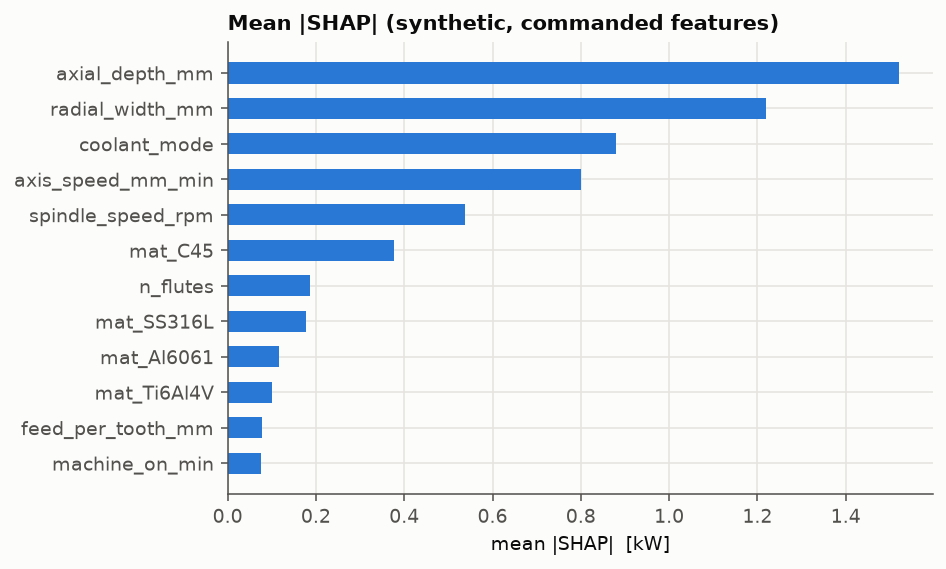

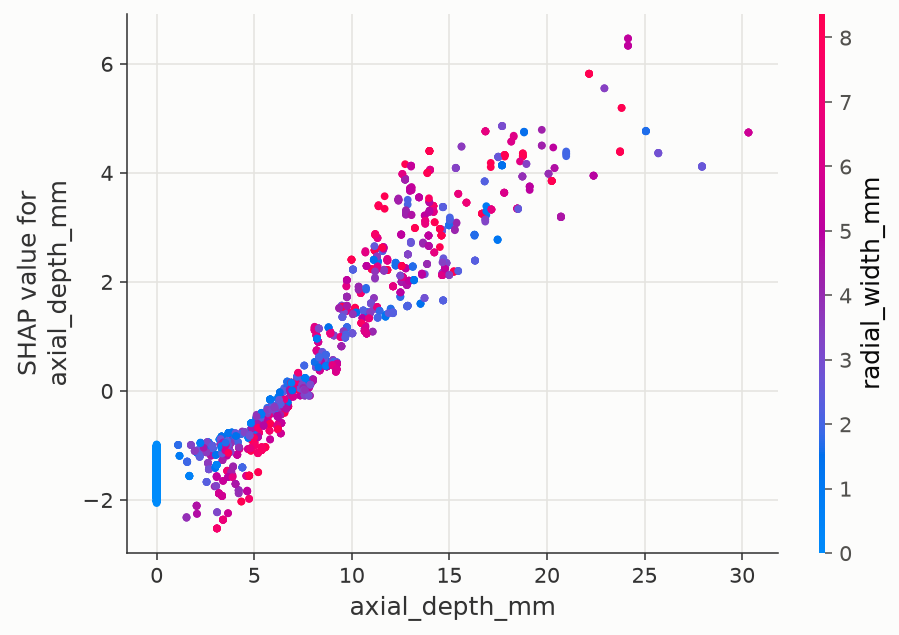

In [5]:
show('e09_shap_bar_synthetic.png', 560); show('e09_shap_dependence_axial_depth_mm.png', 520)

## Energy-residual anomaly detection (E12)
residual = actual − predicted (out-of-fold). Flagged windows are **potential inefficient operating conditions** - not equipment failures.

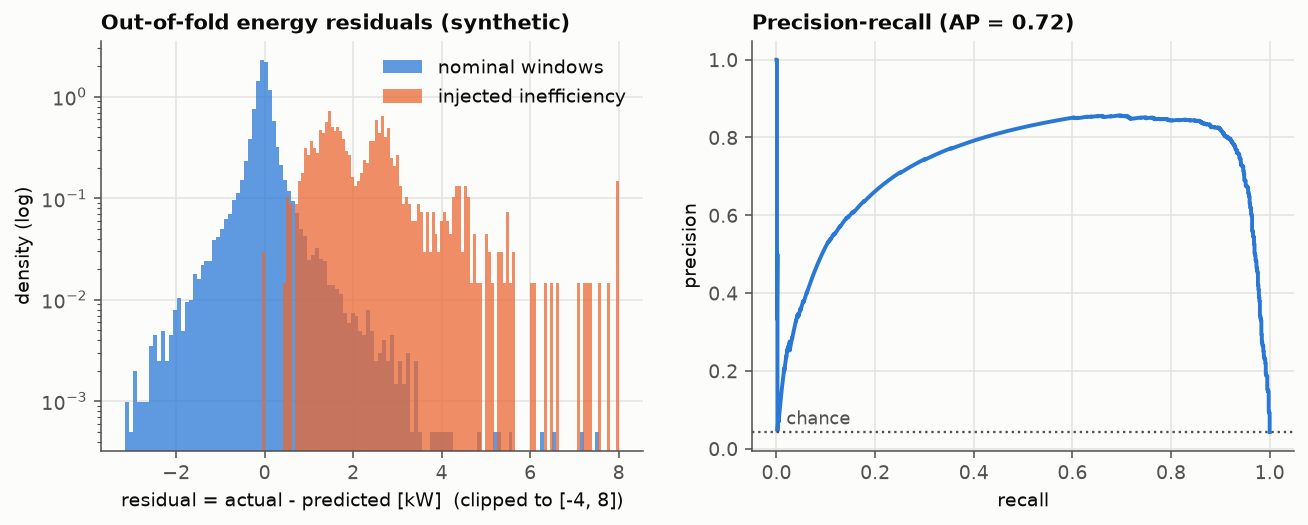

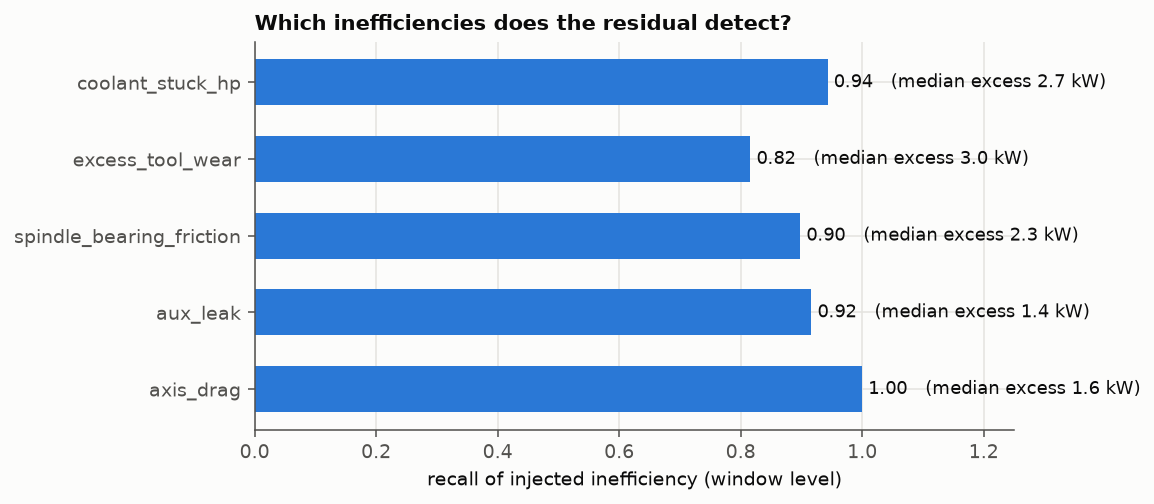

In [6]:
show('e12_residuals_pr_synthetic.png', 900); show('e12_recall_by_type.png', 620)

In [7]:
a = json.load(open(RES/'E12_anomaly.json'))
pd.DataFrame({k: {m: v for m, v in a[k].items() if not isinstance(v, dict)} for k in ['in_distribution_oof', 'extrapolation_ood_jobs']}).round(3)

,in_distribution_oof,extrapolation_ood_jobs
rows,23678.000,3289.000
true_inefficient_windows,1008.000,177.000
flagged,1120.000,155.000
tp,913.000,108.000
fp,207.000,47.000
fn,95.000,69.000
precision,0.815,0.697
recall,0.906,0.610
f1,0.858,0.651
average_precision,0.723,0.666


In [8]:
f = pd.read_csv(TAB/'e12_flagged_windows_synthetic.csv')
f[['job_id','material','spindle_speed_rpm','axial_depth_mm','coolant_mode','power_kw','pred','resid','z','gt_job_anomaly']].sort_values('z', ascending=False).head(10).round(2)

,job_id,material,spindle_speed_rpm,axial_depth_mm,coolant_mode,power_kw,pred,resid,z,gt_job_anomaly
781,1690,SS316L,3165.02,0.0,1,25.63,6.19,19.44,184.68,coolant_stuck_hp
837,1799,SS316L,2088.81,0.0,1,13.92,4.95,8.97,134.24,none
71,146,C45,3064.17,0.0,1,14.01,5.19,8.82,131.85,none
187,385,Ti6Al4V,1327.78,0.0,2,25.19,7.50,17.69,116.83,aux_leak
890,1953,Ti6Al4V,1277.69,0.0,2,26.62,8.45,18.17,99.08,spindle_bearing_friction
0,5,Ti6Al4V,3367.68,0.0,1,16.35,6.22,10.13,96.27,none
91,174,Al6061,7969.51,0.0,1,22.37,7.82,14.55,96.12,none
18,46,C45,1569.20,0.0,1,15.78,5.74,10.04,95.42,none
938,2137,SS316L,1806.16,0.0,1,11.24,4.86,6.38,95.36,none
1022,2258,Al6061,7959.82,0.0,1,23.56,7.95,15.61,95.10,none


Real data: rows with unusually high spindle power given their recorded inputs (no ground truth, candidates for inspection only).

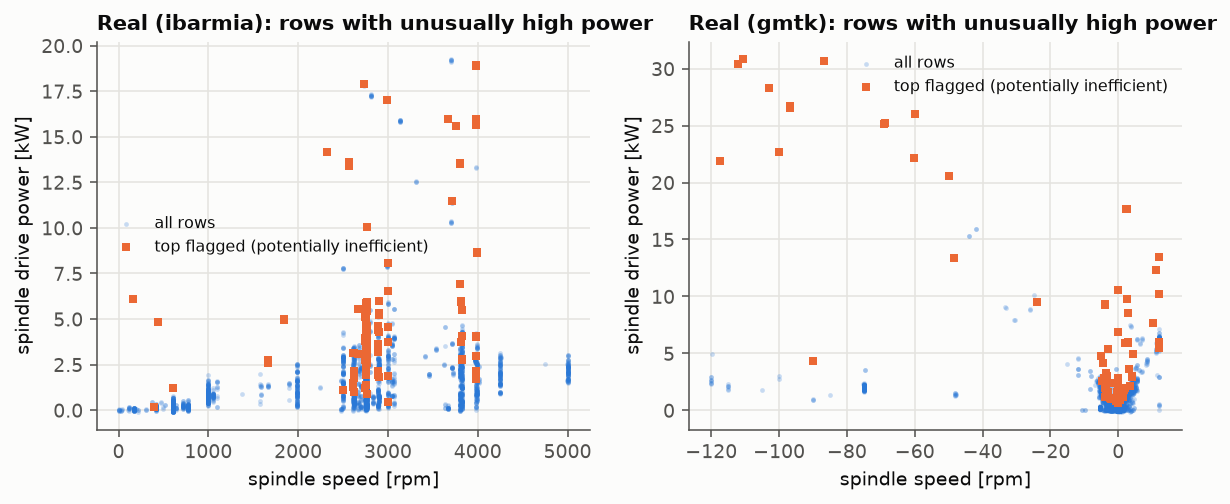

In [9]:
show('e12_real_flagged.png', 900)

## Optimisation (E13) - PREDICTED / SIMULATED savings
Minimise energy over a fixed takt window (standby included) subject to: same cycle time, spindle power/torque, tool life, cutting-speed window, training-data ranges, MRR within the model's trust region.
Current conditions = recorded settings of 440 unseen jobs; recommended = optimiser output; savings verified in the noise-free simulator.

In [10]:
o = json.load(open(RES/'E13_optimization.json'))
pd.DataFrame({k: {m: v for m, v in o[k].items() if m != 'label'} for k in ['A_final_model_window_objective', 'A_final_model_operation_objective']}).T.round(3)

,jobs,mean_saving_true_pct,ci95,median_saving_true_pct,p10,p90,mean_saving_pred_pct,mean_saving_true_operation_only_pct,share_power_limit_active,share_tool_life_limit_active,share_trust_limit_active,mean_vars_at_upper_bound,mean_time_ratio_opt_over_base,share_improved_true,share_worse_true,baseline_infeasible_share,no_feasible_found_share,true_overload_opt_share,true_overload_base_share,total_kwh_base_true,total_kwh_opt_true,total_saving_true_pct,mrr_ratio_median
A_final_model_window_objective,440,37.165437,"[35.79184407340185, 38.57201453051356]",37.895163,17.79261,55.747708,39.640744,58.139916,0.102273,0.0,0.415909,0.170455,0.339195,1.0,0.0,0.122727,0.0,0.0,0.0,1521.036275,993.668853,34.671587,3.914878
A_final_model_operation_objective,440,58.614087,"[56.35510499732471, 60.84213206611]",60.789153,24.329391,88.529503,60.788925,58.614087,0.111364,0.0,0.456818,0.225,0.326421,1.0,0.0,0.122727,0.0,0.0,0.0,1521.036275,703.810902,53.728197,4.061124


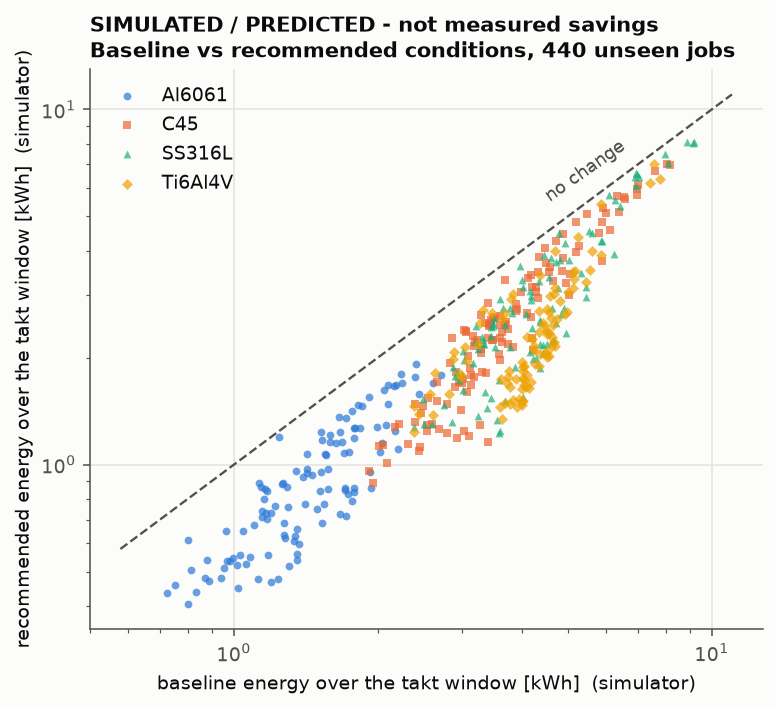

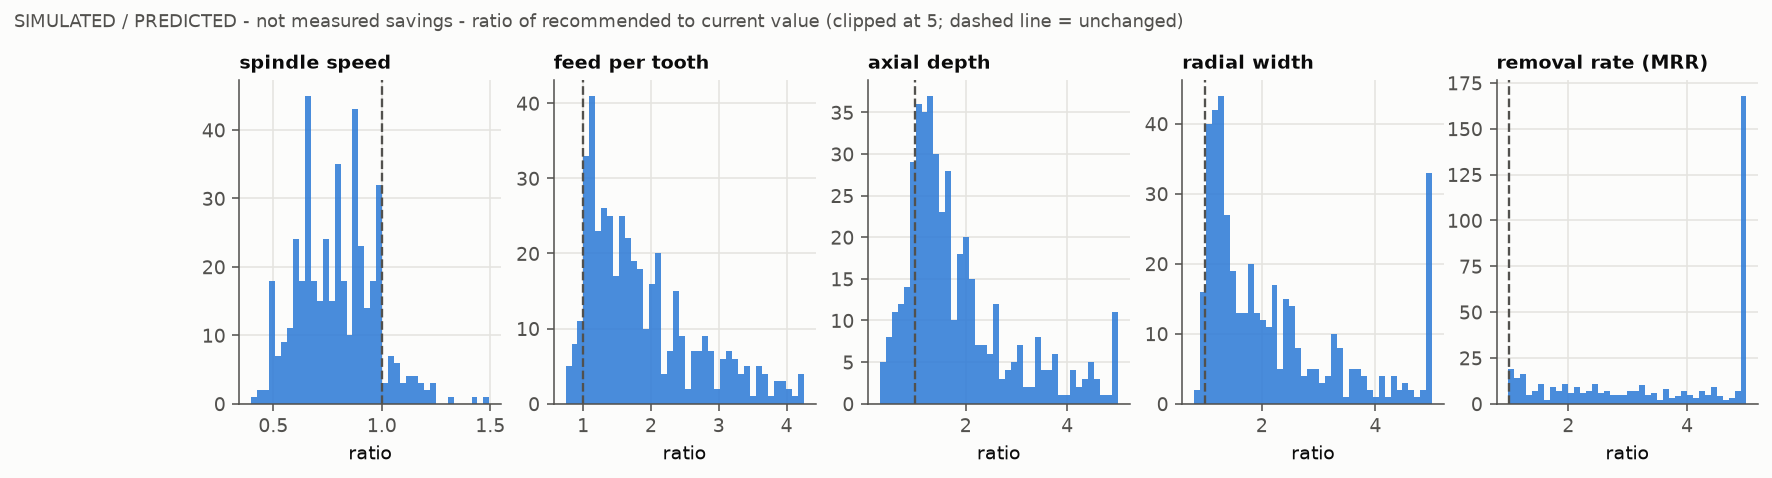

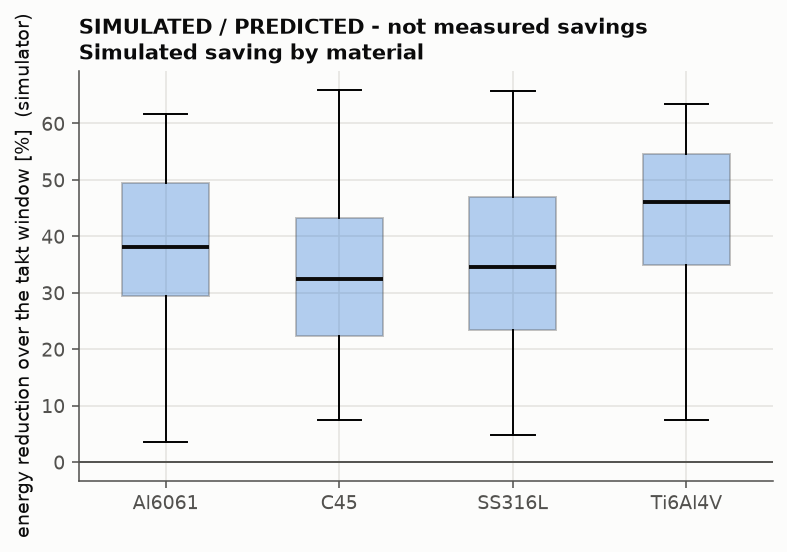

In [11]:
show('e13_before_after.png', 620); show('e13_parameter_shift.png', 980); show('e13_saving_by_material.png', 560)

### Does the recommendation survive the simulator? (which model the optimiser uses matters)

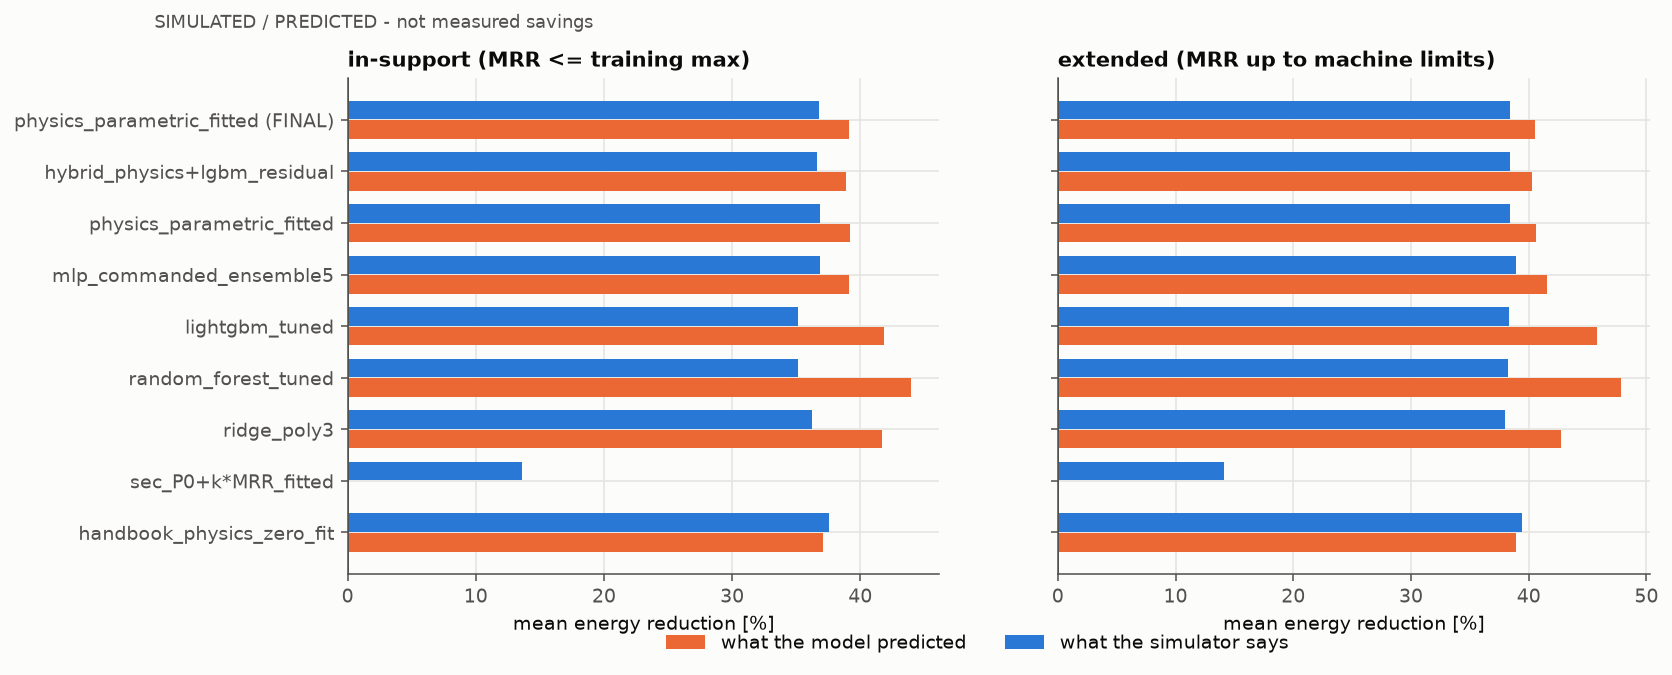

In [12]:
show('e13_model_comparison.png', 980)

In [13]:
pd.read_csv(TAB/'e13_model_comparison.csv')[['model','regime','mean_saving_pred_pct','mean_saving_true_pct','true_overload_opt_share']].round(2)

,model,regime,mean_saving_pred_pct,mean_saving_true_pct,true_overload_opt_share
0,handbook_physics_zero_fit,in-support (MRR <= training max),37.10,37.56,0.0
1,handbook_physics_zero_fit,extended (MRR up to machine limits),38.93,39.42,0.0
2,sec_P0+k*MRR_fitted,in-support (MRR <= training max),0.00,13.58,0.0
3,sec_P0+k*MRR_fitted,extended (MRR up to machine limits),0.00,14.12,0.0
4,ridge_poly3,in-support (MRR <= training max),41.69,36.22,0.0
5,ridge_poly3,extended (MRR up to machine limits),42.75,37.97,0.0
6,random_forest_tuned,in-support (MRR <= training max),43.98,35.14,0.0
7,random_forest_tuned,extended (MRR up to machine limits),47.87,38.28,0.0
8,lightgbm_tuned,in-support (MRR <= training max),41.83,35.15,0.0
9,lightgbm_tuned,extended (MRR up to machine limits),45.78,38.31,0.0


In [14]:
jobs = pd.read_csv(TAB/'e13_job_results_final_model.csv')
jobs[['job_id','material','n_base','n_opt','fz_base','fz_opt','ap_base','ap_opt','ae_base','ae_opt','t_op_base_min','t_op_opt_min','e_true_base','e_true_opt','save_true_pct','save_pred_pct']].head(10).round(3)

,job_id,material,n_base,n_opt,fz_base,fz_opt,ap_base,ap_opt,ae_base,ae_opt,t_op_base_min,t_op_opt_min,e_true_base,e_true_opt,save_true_pct,save_pred_pct
0,5,Ti6Al4V,3384.167,3085.096,0.028,0.058,4.611,6.259,3.317,3.888,30.851,10.709,3.239,2.191,32.356,32.724
1,14,C45,6273.000,3847.772,0.063,0.129,10.469,12.153,4.119,6.481,19.418,8.855,3.917,2.745,29.931,32.277
2,18,Ti6Al4V,1681.802,1610.136,0.063,0.117,8.423,12.482,6.446,7.791,26.823,8.693,2.885,2.073,28.155,28.606
3,21,C45,4512.762,3186.011,0.081,0.151,4.622,13.906,3.340,7.340,15.986,1.927,2.046,1.132,44.659,45.580
4,44,Ti6Al4V,1125.684,1260.612,0.065,0.117,7.530,12.584,3.910,7.748,26.785,4.156,3.761,1.840,51.078,50.358
5,48,SS316L,4018.745,2463.880,0.039,0.110,7.354,12.627,1.177,6.492,23.146,1.461,2.504,1.302,48.019,49.674
6,49,Al6061,7990.463,6369.200,0.057,0.117,6.416,13.490,5.289,6.491,9.705,2.482,1.148,0.711,38.037,38.655
7,57,C45,6676.470,3890.321,0.110,0.130,8.372,14.903,1.578,6.480,25.093,4.630,3.841,2.141,44.265,47.035
8,60,SS316L,2100.371,1859.490,0.054,0.132,11.915,15.121,4.528,7.774,23.235,5.270,4.622,2.751,40.478,41.169
9,62,C45,4494.813,2405.953,0.088,0.207,13.994,12.581,5.275,10.316,21.503,10.010,4.645,3.289,29.194,38.899


### Limits of the optimisation claim
* The baseline is a *sampled* practice distribution, often far below the simulated machine's capability; real plants are already bounded by chatter, surface finish, fixture rigidity and tool-change rules that are not modelled.
* The absolute percentage is therefore an upper bound inside the simulator. Robust take-aways: fixed loads dominate (so finishing sooner matters), spindle speed should not be higher than needed, and tree models must not be trusted at the edge of their data.